# Hyperparameter Tuning and Model Optimization (Part 6)

This notebook presents the systematic hyperparameter tuning phase of the **Heart Disease Prediction** project.


## 1. Objective

The primary objective of Part 6 is to scientifically tune promising baseline machine learning classifiers using 5-Fold Stratified Cross-Validation on the 242-row training set (`X_train_raw`) with `ROC-AUC` as the primary optimization metric while keeping the 61-row test set completely untouched and locked.


## 2. Why Hyperparameter Tuning?

Baseline models use default hyperparameters which may not be optimal for a specific clinical dataset. Systematic hyperparameter tuning explores structural hyperparameters (e.g., regularization strength C, tree depth, learning rate, distance metrics) within leak-free cross-validation pipelines to improve decision boundary calibration without overfitting.


## 3. Models Selected

Exactly 5 baseline classifiers are tuned:
1. **Logistic Regression** (`GridSearchCV`)
2. **Support Vector Machine (SVM)** (`GridSearchCV`)
3. **Random Forest** (`RandomizedSearchCV`, `n_iter=60`)
4. **XGBoost** (`RandomizedSearchCV`, `n_iter=60`)
5. **K-Nearest Neighbors (KNN)** (`GridSearchCV`)

*Note: Decision Tree and Gaussian Naive Bayes baseline models were excluded from tuning as per specification to serve as untouched baseline references.*


## 4. Test-Set Protection

To prevent data leakage and optimistic hyperparameter selection bias:
- **Training Set (242 rows)**: Used exclusively for parameter searching, cross-validation scoring, parameter selection, and pre-test model ranking.
- **Test Set (61 rows)**: Kept locked and was NOT used to choose search spaces, select winning configurations, or evaluate candidate parameters.
- **Configuration Freeze**: All winning parameter configurations were frozen into `frozen_tuned_configurations.json` BEFORE the test set was unlocked for a single-pass evaluation.


## 5. Cross-Validation Strategy

All hyperparameter searches used **Stratified 5-Fold Cross-Validation** (`StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`).
Inside every CV fold, preprocessing transformers (imputers, scalers, encoders) were fitted strictly on the 4/5 training fold and applied to the 1/5 validation fold to prevent data leakage.


## 6. Search Spaces

Search spaces were defined over full scikit-learn pipelines using `classifier__` parameter prefixes:


In [1]:
from pathlib import Path
import pandas as pd
import json

metrics_dir = Path("../results/metrics/tuning/")
if not metrics_dir.exists():
    metrics_dir = Path("results/metrics/tuning/")

search_summary_df = pd.read_csv(metrics_dir / "search_summary.csv")
search_summary_df


,Model,Search_Method,Candidate_Configurations,CV_Folds,Approximate_Fits_Performed,Best_CV_ROC_AUC
0,Logistic Regression,GridSearchCV,36,5,180,0.907032
1,Support Vector Machine,GridSearchCV,70,5,350,0.904743
2,Random Forest,RandomizedSearchCV,60,5,300,0.904086
3,XGBoost,RandomizedSearchCV,60,5,300,0.906081
4,K-Nearest Neighbors,GridSearchCV,108,5,540,0.899634


## 7. Best Parameters

The optimal hyperparameter combinations selected via 5-fold cross-validated ROC-AUC on the training set:


In [2]:
with open(metrics_dir / "best_parameters.json") as f:
    best_params_json = json.load(f)

for model, data in best_params_json.items():
    print(f"=== {model} ({data['search_method']}) ===")
    print(f"Best CV ROC-AUC: {data['best_cv_roc_auc']:.4f}")
    print(f"Parameters:      {data['clean_best_params']}\n")


=== Logistic Regression (GridSearchCV) ===
Best CV ROC-AUC: 0.9070
Parameters:      {'C': 1, 'class_weight': None, 'penalty': 'l1', 'solver': 'liblinear'}

=== Support Vector Machine (GridSearchCV) ===
Best CV ROC-AUC: 0.9047
Parameters:      {'C': 0.1, 'class_weight': None, 'kernel': 'linear'}

=== Random Forest (RandomizedSearchCV) ===
Best CV ROC-AUC: 0.9041
Parameters:      {'n_estimators': 500, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None, 'class_weight': 'balanced_subsample'}

=== XGBoost (RandomizedSearchCV) ===
Best CV ROC-AUC: 0.9061
Parameters:      {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 100, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 0.7}

=== K-Nearest Neighbors (GridSearchCV) ===
Best CV ROC-AUC: 0.8996
Parameters:      {'metric': 'manhattan', 'n_neighbors': 11, 'p': 1, 'weights': 'distance'}



## 8. Tuned CV Performance

Cross-validated performance of the best tuned pipelines on the 242-row training set:


In [3]:
tuned_cv_df = pd.read_csv(metrics_dir / "tuned_cv_results.csv")
tuned_cv_df


,Model,CV_Accuracy_Mean,CV_Accuracy_Std,CV_Precision_Mean,CV_Precision_Std,CV_Recall_Mean,CV_Recall_Std,CV_F1_Mean,CV_F1_Std,CV_ROC_AUC_Mean,CV_ROC_AUC_Std
0,Logistic Regression,0.834694,0.013281,0.853924,0.059690,0.783399,0.067733,0.812256,0.017305,0.907032,0.011448
1,Support Vector Machine,0.830442,0.035784,0.879975,0.059047,0.737549,0.098635,0.796215,0.053611,0.904743,0.019462
2,Random Forest,0.822109,0.022595,0.814505,0.044547,0.800791,0.085337,0.803131,0.034026,0.904086,0.028241
3,XGBoost,0.834609,0.029686,0.863595,0.069033,0.773518,0.100675,0.808210,0.042322,0.906081,0.023930
4,K-Nearest Neighbors,0.826361,0.021676,0.831774,0.029518,0.783004,0.084509,0.802913,0.037478,0.899634,0.032436


## 9. Pre-Test Model Ranking

Objective model ranking established BEFORE test set evaluation, sorted primarily by CV ROC-AUC:


In [4]:
pre_rank_df = pd.read_csv(metrics_dir / "pre_test_model_ranking.csv")
pre_rank_df


,Pre_Test_Rank,Model,CV_ROC_AUC_Mean,CV_ROC_AUC_Std,CV_F1_Mean,CV_Recall_Mean,CV_Accuracy_Mean,CV_Precision_Mean
0,1,Logistic Regression,0.907032,0.011448,0.812256,0.783399,0.834694,0.853924
1,2,XGBoost,0.906081,0.023930,0.808210,0.773518,0.834609,0.863595
2,3,Support Vector Machine,0.904743,0.019462,0.796215,0.737549,0.830442,0.879975
3,4,Random Forest,0.904086,0.028241,0.803131,0.800791,0.822109,0.814505
4,5,K-Nearest Neighbors,0.899634,0.032436,0.802913,0.783004,0.826361,0.831774


## 10. Tuned Test Performance

Single-pass test set evaluation on the 61 held-out test rows after configuration freezing:


In [5]:
tuned_test_df = pd.read_csv(metrics_dir / "tuned_test_results.csv")
tuned_test_df


,Model,Accuracy,Precision,Recall,Specificity,F1,ROC_AUC,TN,FP,FN,TP
0,Logistic Regression,0.868852,0.833333,0.892857,0.848485,0.862069,0.958874,28,5,3,25
1,Support Vector Machine,0.836066,0.800000,0.857143,0.818182,0.827586,0.942641,27,6,4,24
2,Random Forest,0.901639,0.843750,0.964286,0.848485,0.900000,0.956710,28,5,1,27
3,XGBoost,0.868852,0.833333,0.892857,0.848485,0.862069,0.954545,28,5,3,25
4,K-Nearest Neighbors,0.885246,0.862069,0.892857,0.878788,0.877193,0.962121,29,4,3,25


## 11. Baseline vs Tuned

Comparison of baseline performance vs tuned performance across cross-validation and test metrics:


In [6]:
b_vs_t_df = pd.read_csv(metrics_dir / "baseline_vs_tuned.csv")
b_vs_t_df


,Model,Baseline_CV_ROC_AUC,Tuned_CV_ROC_AUC,CV_ROC_AUC_Change,Baseline_CV_F1,Tuned_CV_F1,CV_F1_Change,Baseline_Test_Accuracy,Tuned_Test_Accuracy,Test_Accuracy_Change,Baseline_Test_Recall,Tuned_Test_Recall,Test_Recall_Change,Baseline_Test_F1,Tuned_Test_F1,Test_F1_Change,Baseline_Test_ROC_AUC,Tuned_Test_ROC_AUC,Test_ROC_AUC_Change
0,Logistic Regression,0.902493,0.907032,0.004539,0.824501,0.812256,-0.012245,0.885246,0.868852,-0.016393,0.928571,0.892857,-0.035714,0.881356,0.862069,-0.019287,0.966450,0.958874,-0.007576
1,Support Vector Machine,0.888373,0.904743,0.016370,0.789349,0.796215,0.006865,0.885246,0.836066,-0.049180,0.928571,0.857143,-0.071429,0.881356,0.827586,-0.053770,0.964286,0.942641,-0.021645
2,Random Forest,0.896848,0.904086,0.007238,0.794756,0.803131,0.008374,0.868852,0.901639,0.032787,0.928571,0.964286,0.035714,0.866667,0.900000,0.033333,0.943723,0.956710,0.012987
3,XGBoost,0.859658,0.906081,0.046422,0.770663,0.808210,0.037547,0.836066,0.868852,0.032787,0.928571,0.892857,-0.035714,0.838710,0.862069,0.023359,0.933983,0.954545,0.020563
4,K-Nearest Neighbors,0.871181,0.899634,0.028452,0.798926,0.802913,0.003987,0.885246,0.885246,0.000000,0.892857,0.892857,0.000000,0.877193,0.877193,0.000000,0.952922,0.962121,0.009199


## 12. Confusion Matrices

Confusion matrix visualizations for the 5 tuned models on the 61-row test set:


--- Logistic Regression Confusion Matrix ---


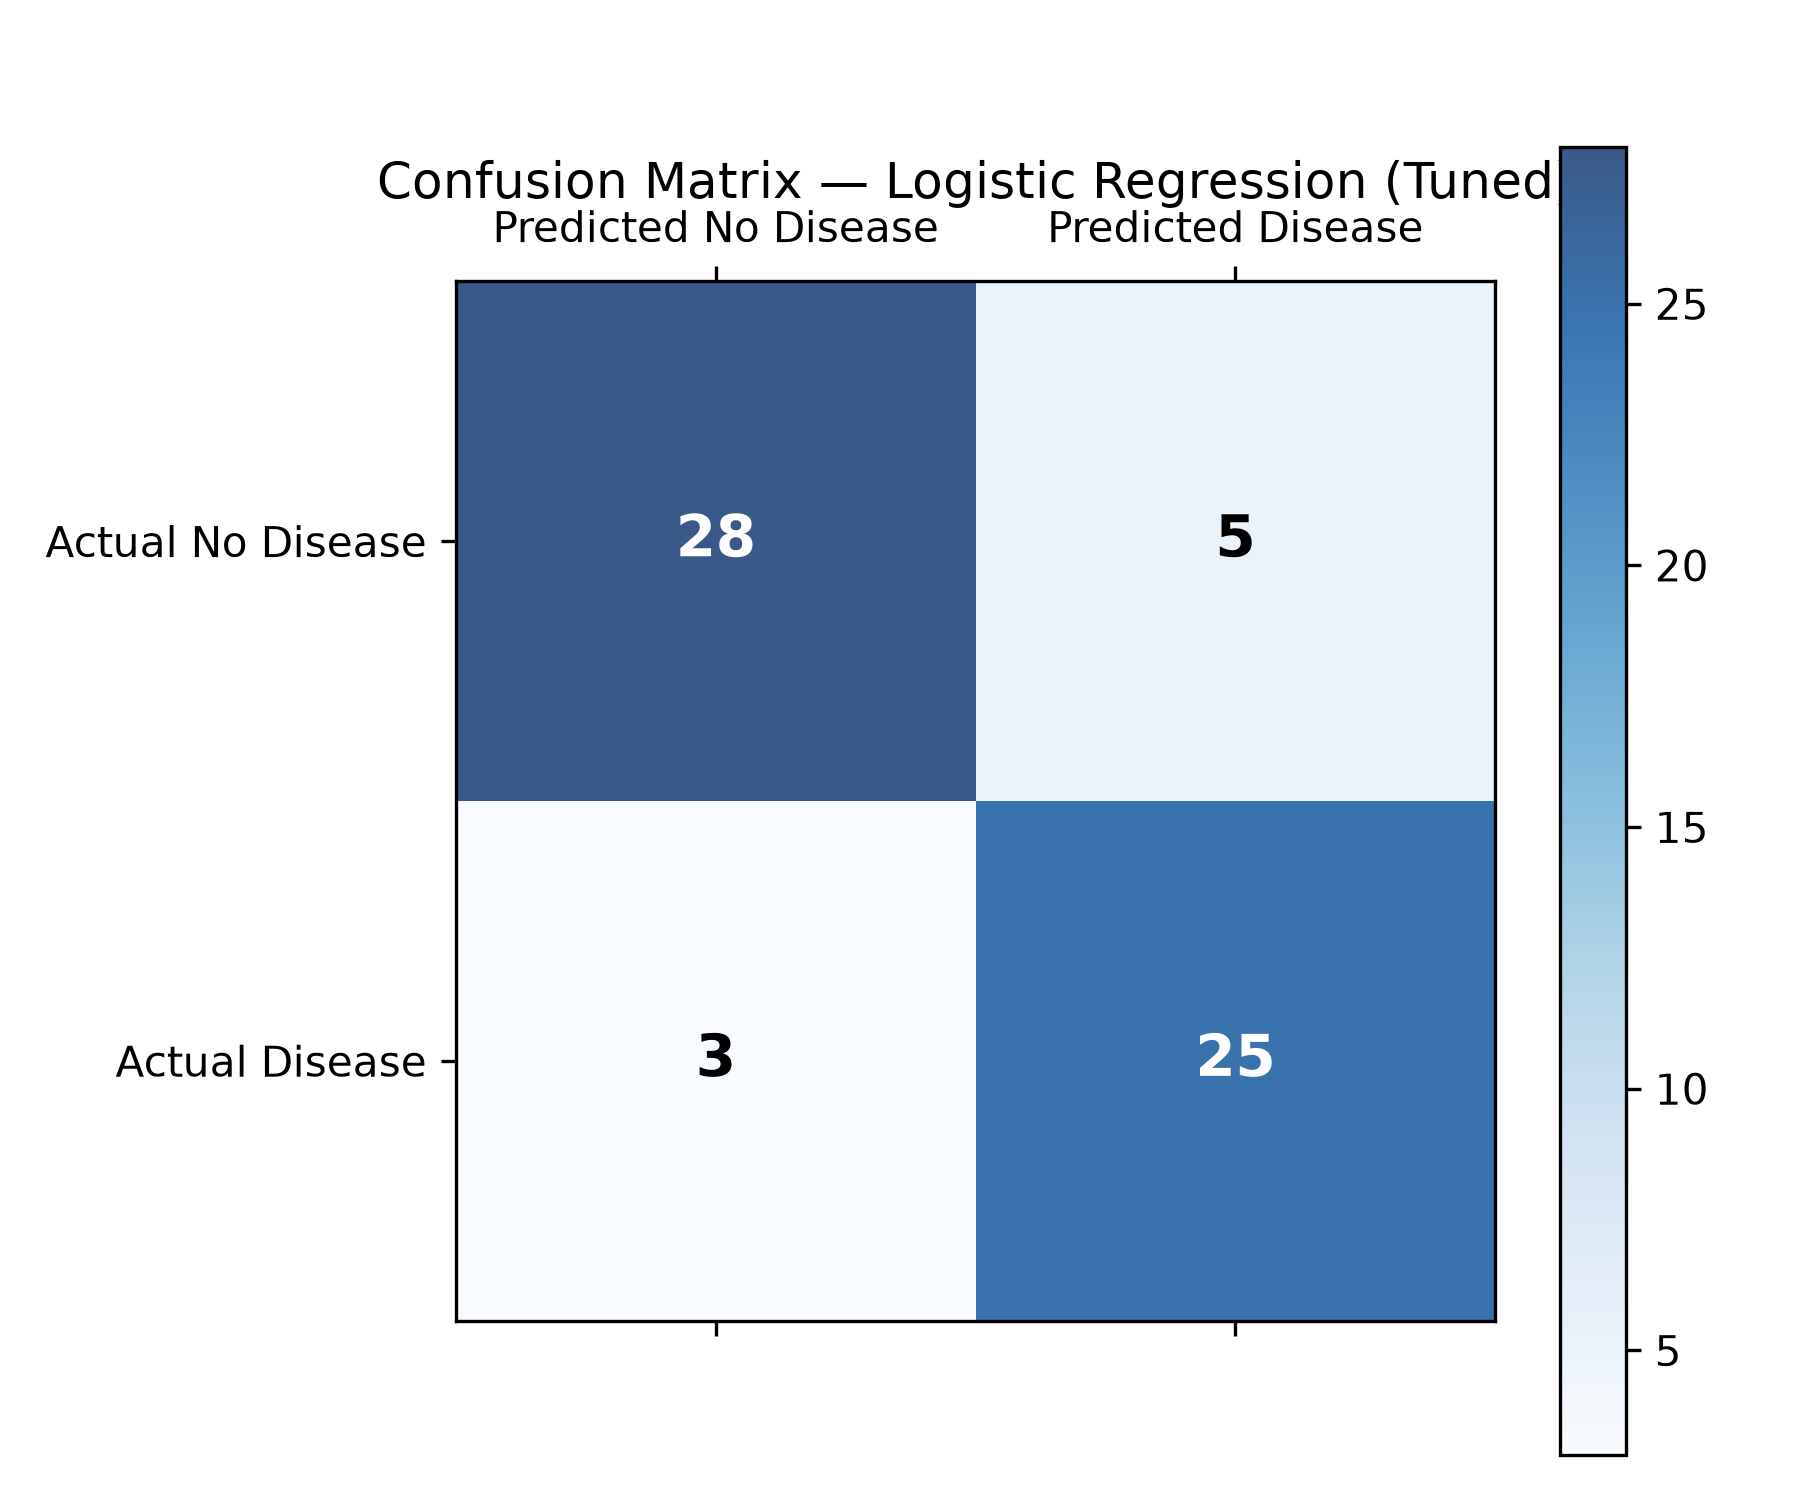

--- Support Vector Machine Confusion Matrix ---


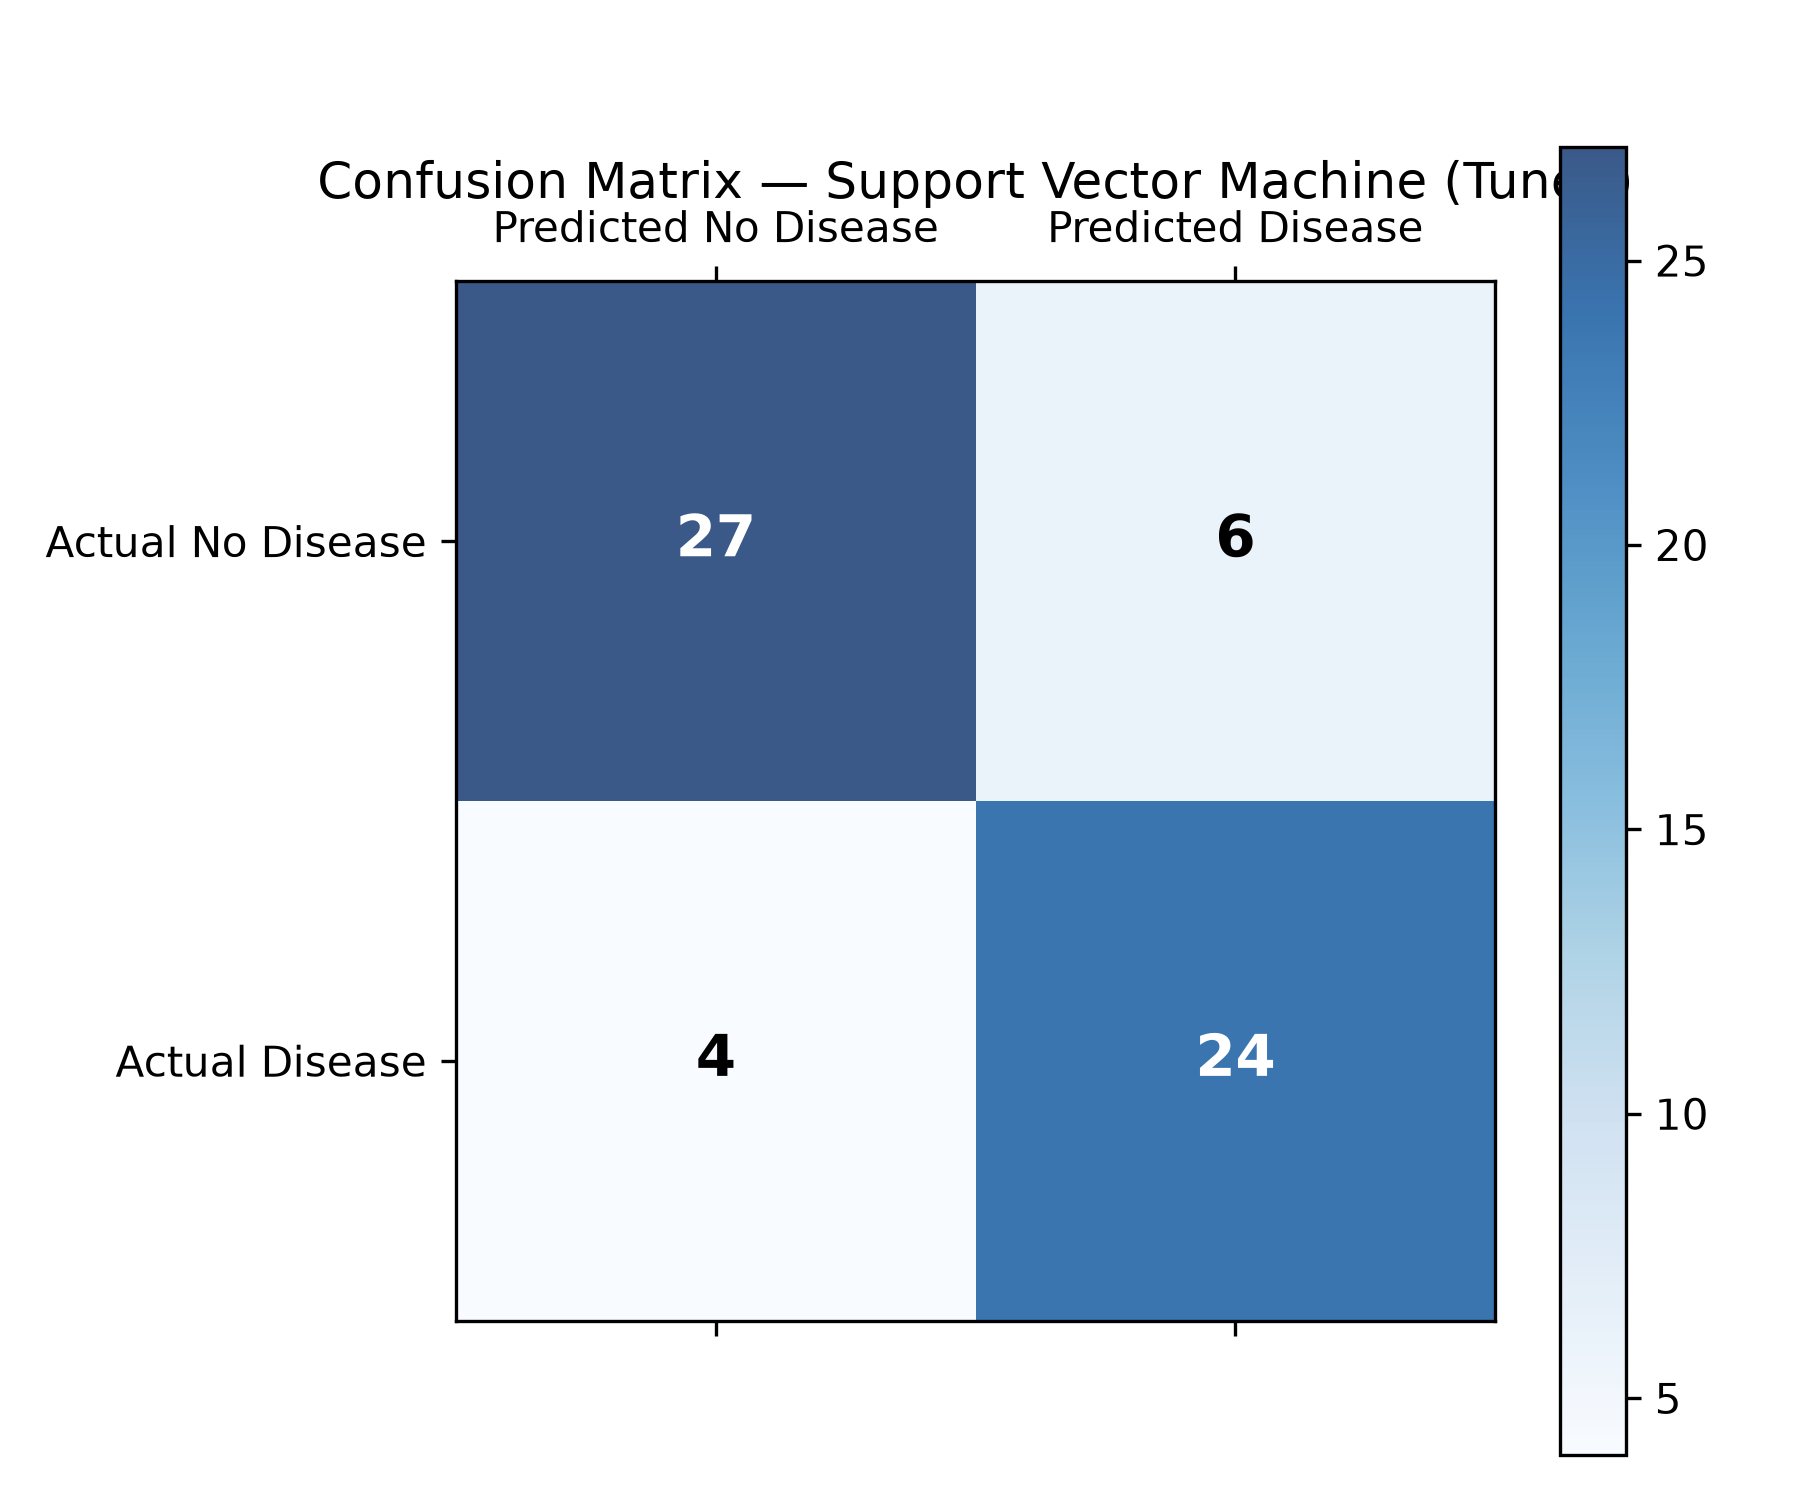

--- Random Forest Confusion Matrix ---


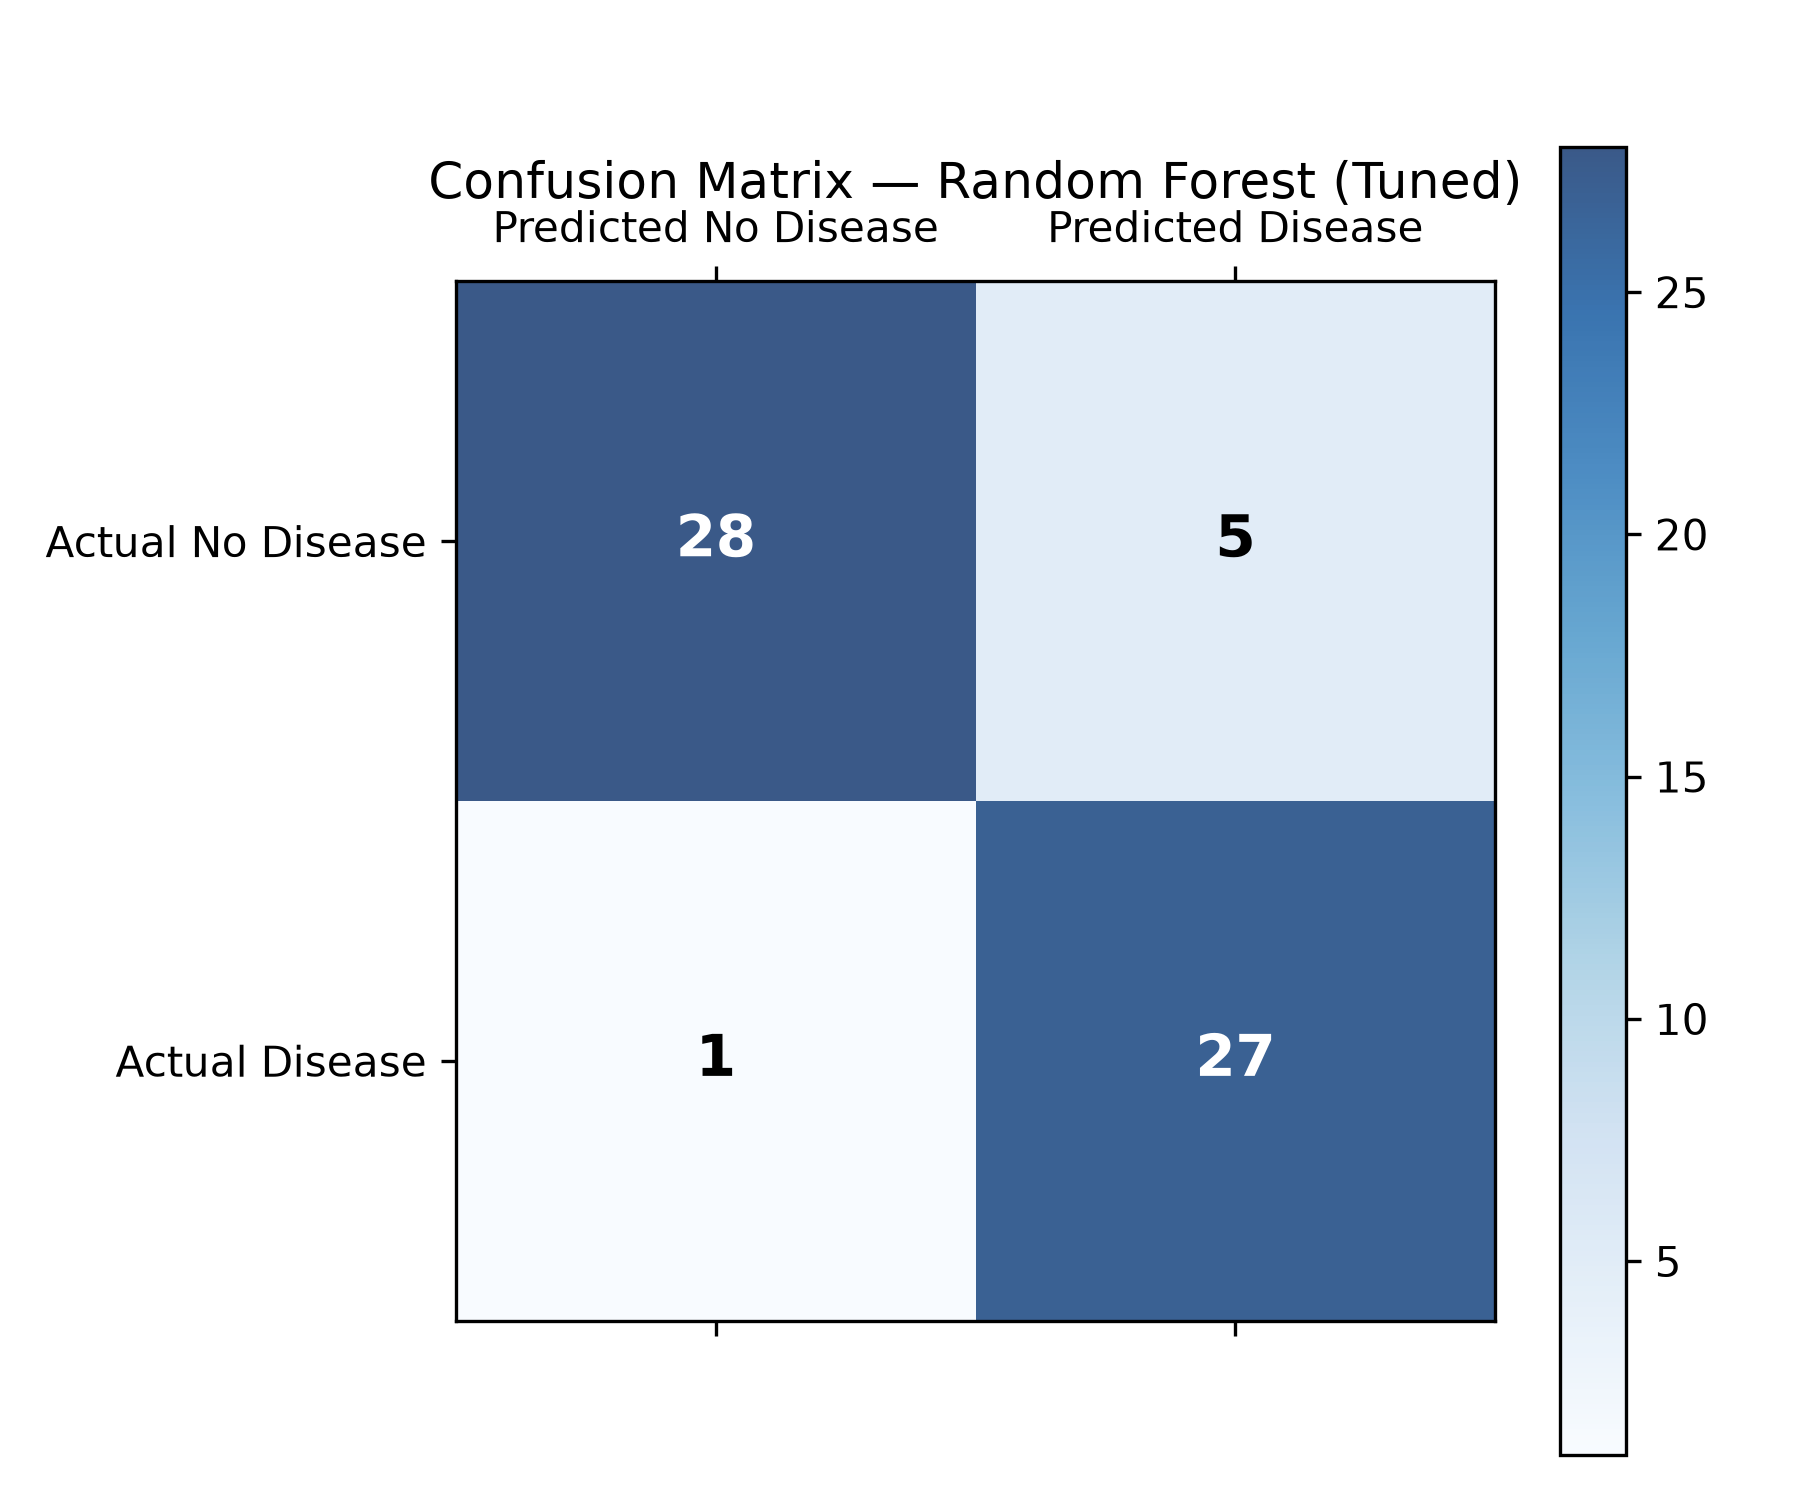

--- Xgboost Confusion Matrix ---


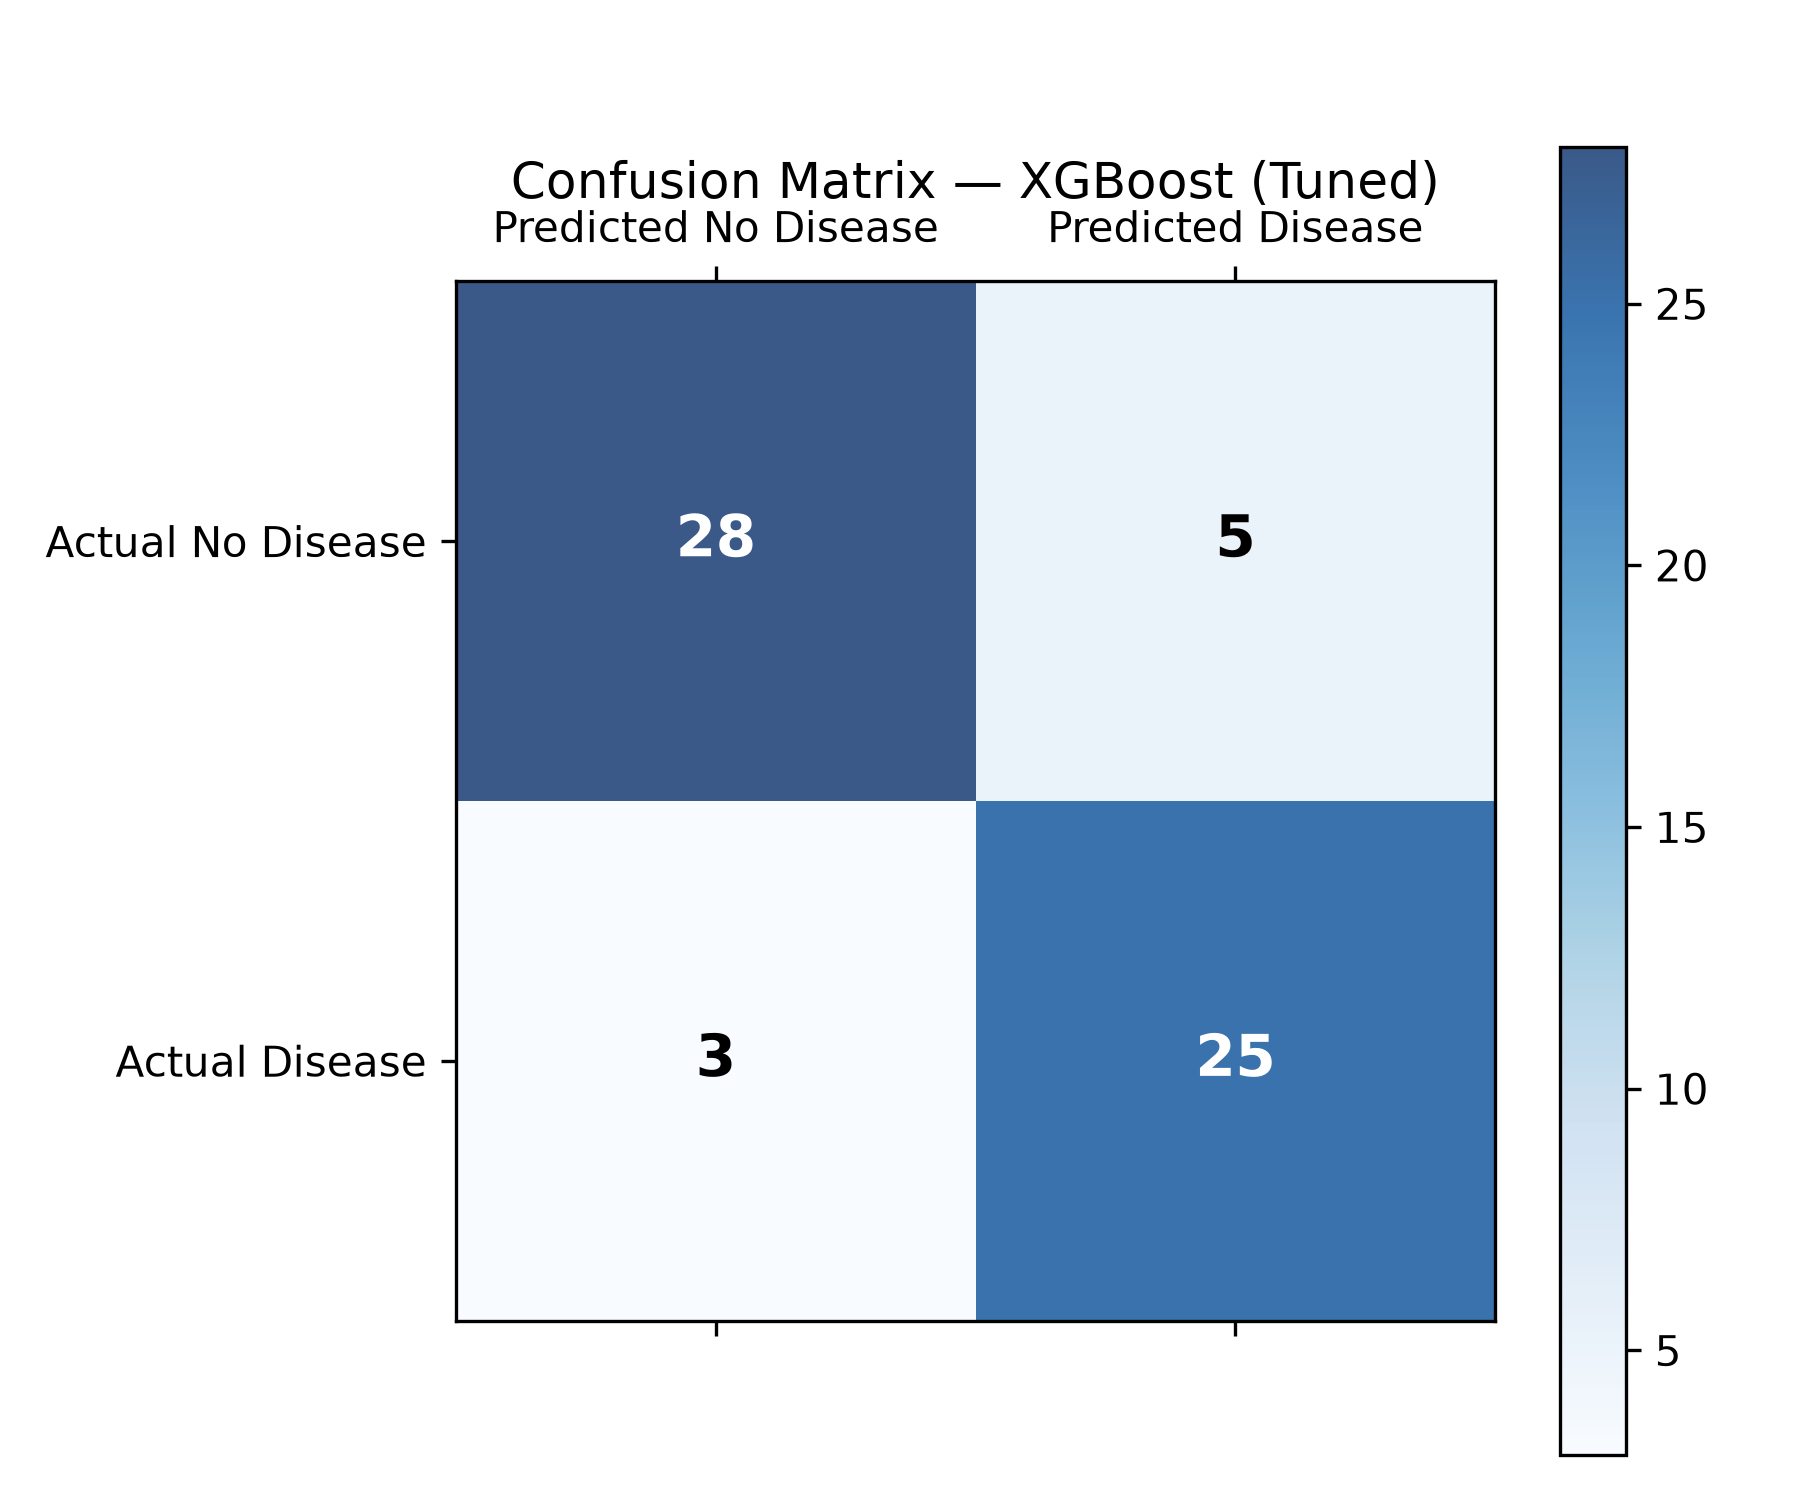

--- K Nearest Neighbors Confusion Matrix ---


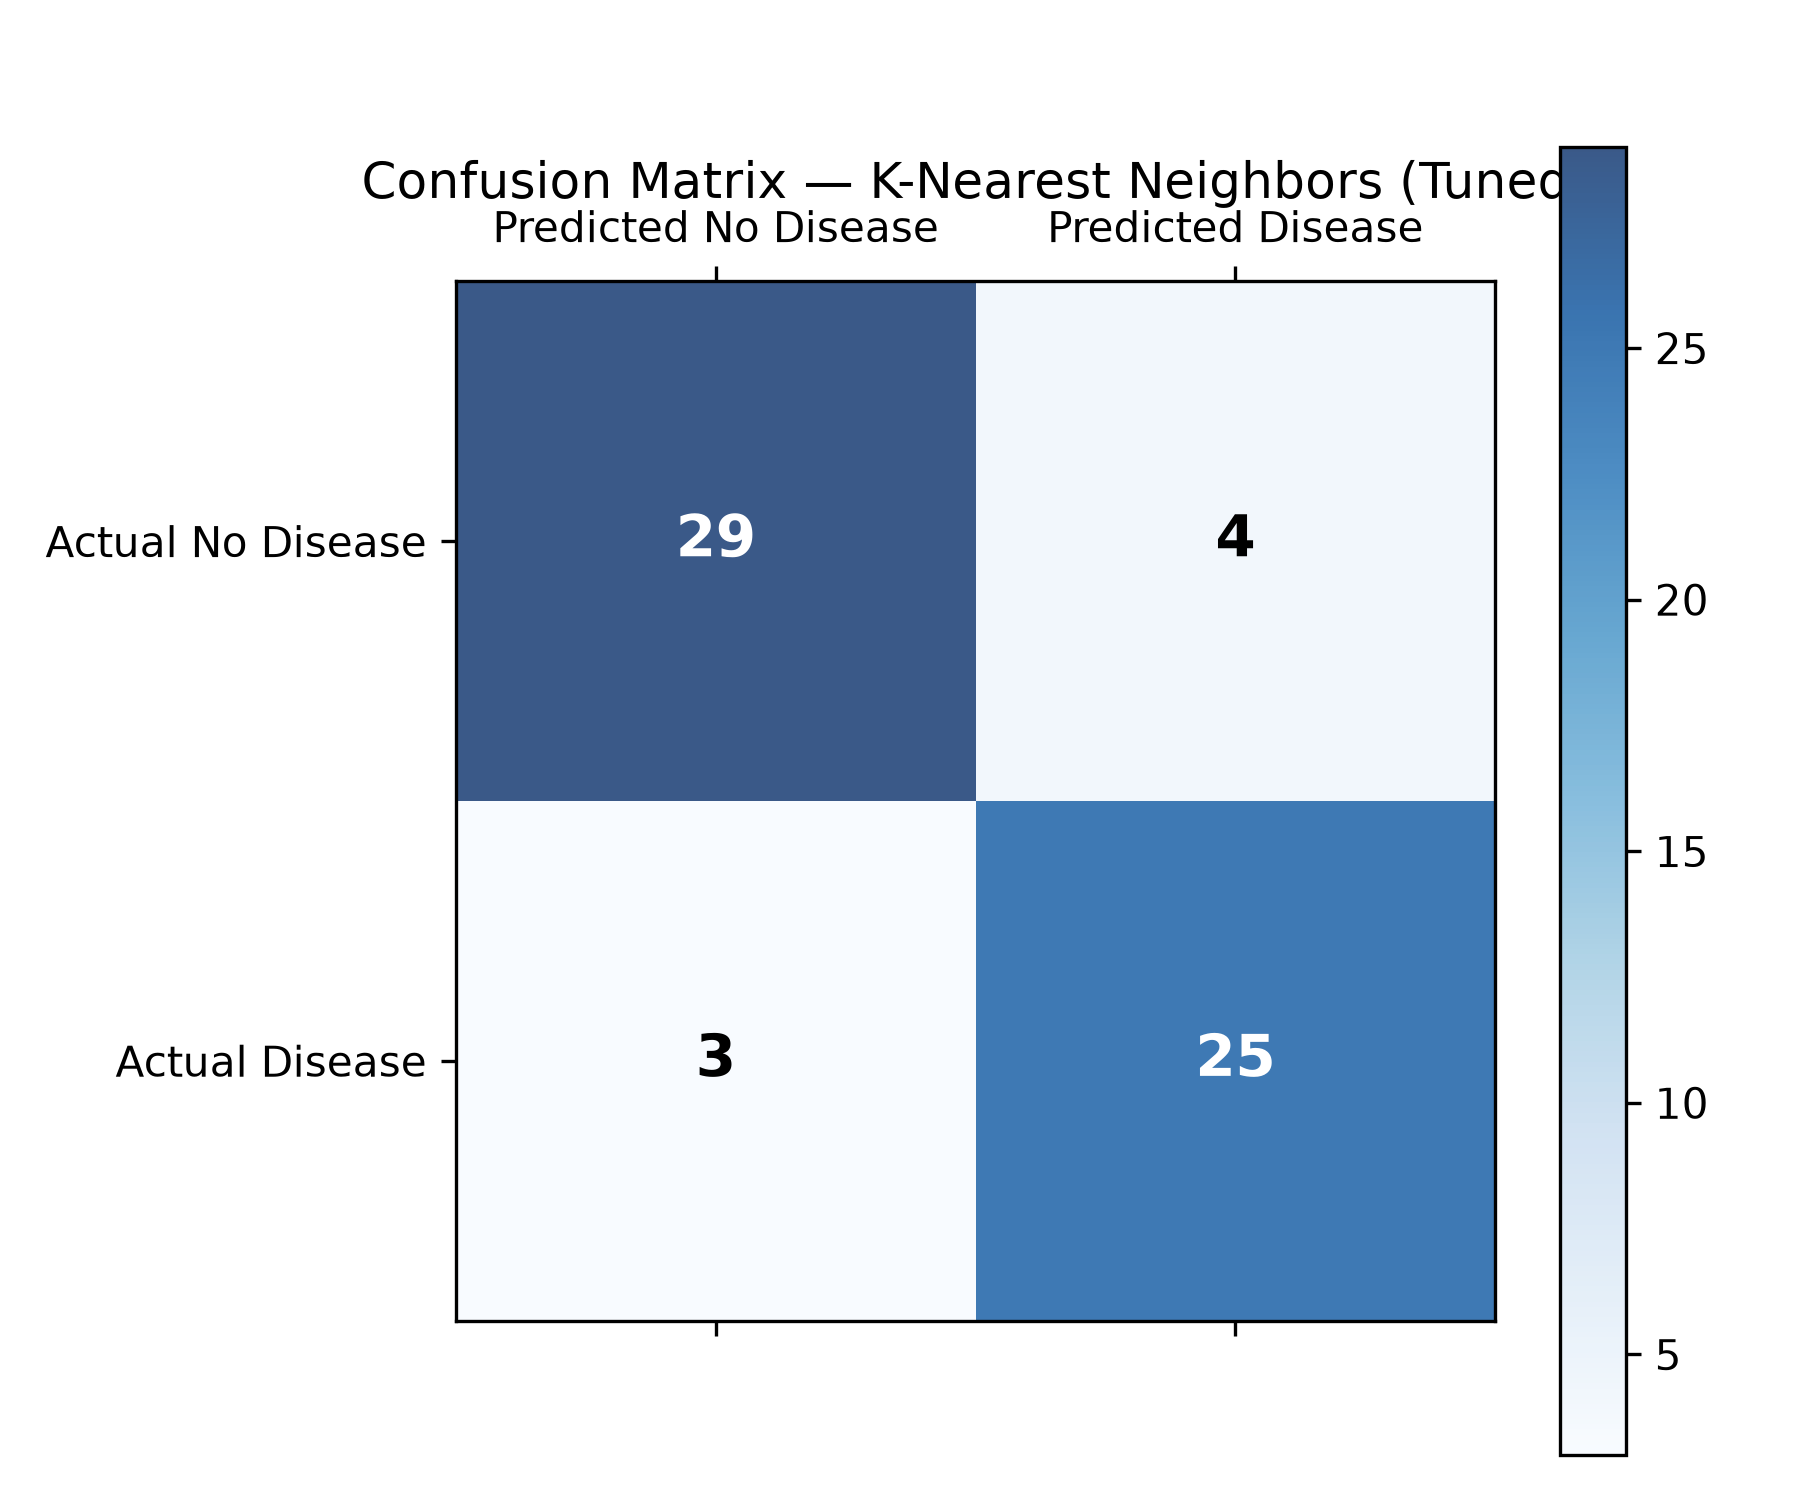

In [7]:
from IPython.display import Image, display

fig_dir = Path("../results/figures/tuning/")
if not fig_dir.exists():
    fig_dir = Path("results/figures/tuning/")

models = ["logistic_regression", "support_vector_machine", "random_forest", "xgboost", "k_nearest_neighbors"]
for m in models:
    cm_file = fig_dir / f"{m}_tuned_confusion_matrix.png"
    if cm_file.exists():
        print(f"--- {m.replace('_', ' ').title()} Confusion Matrix ---")
        display(Image(filename=str(cm_file)))


## 13. ROC Analysis

Combined ROC curves and baseline vs tuned ROC-AUC comparison figures:


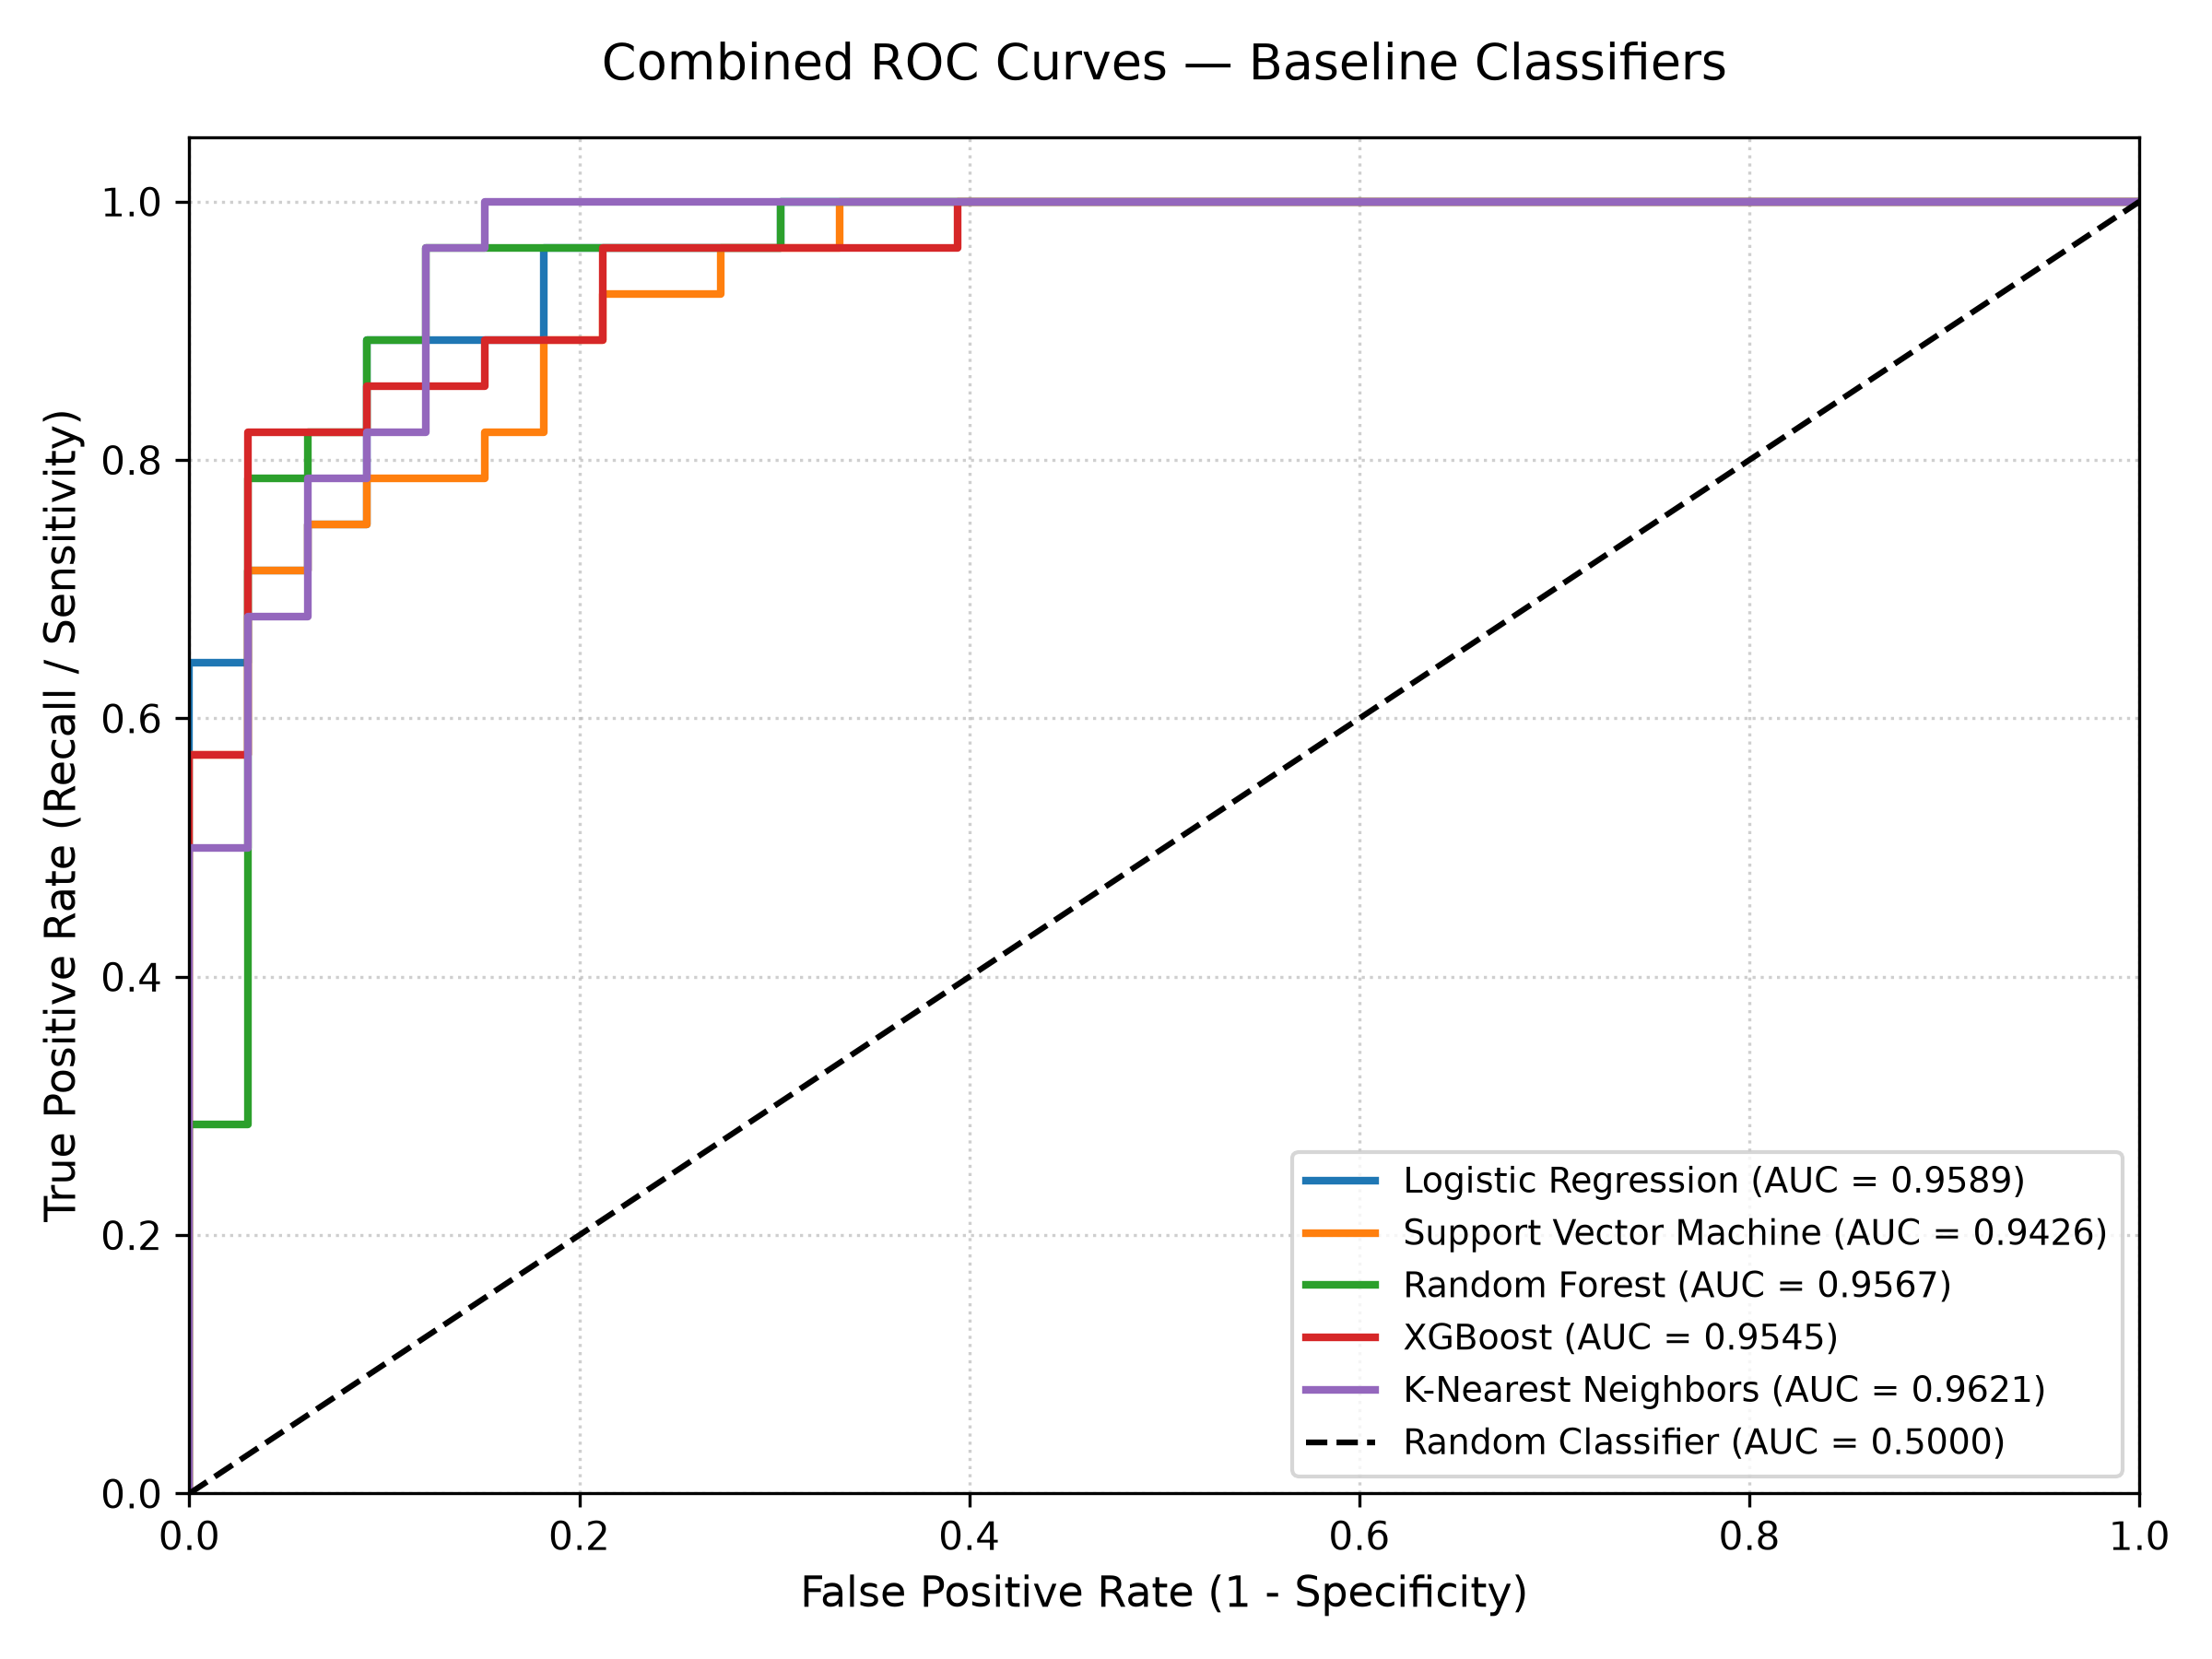

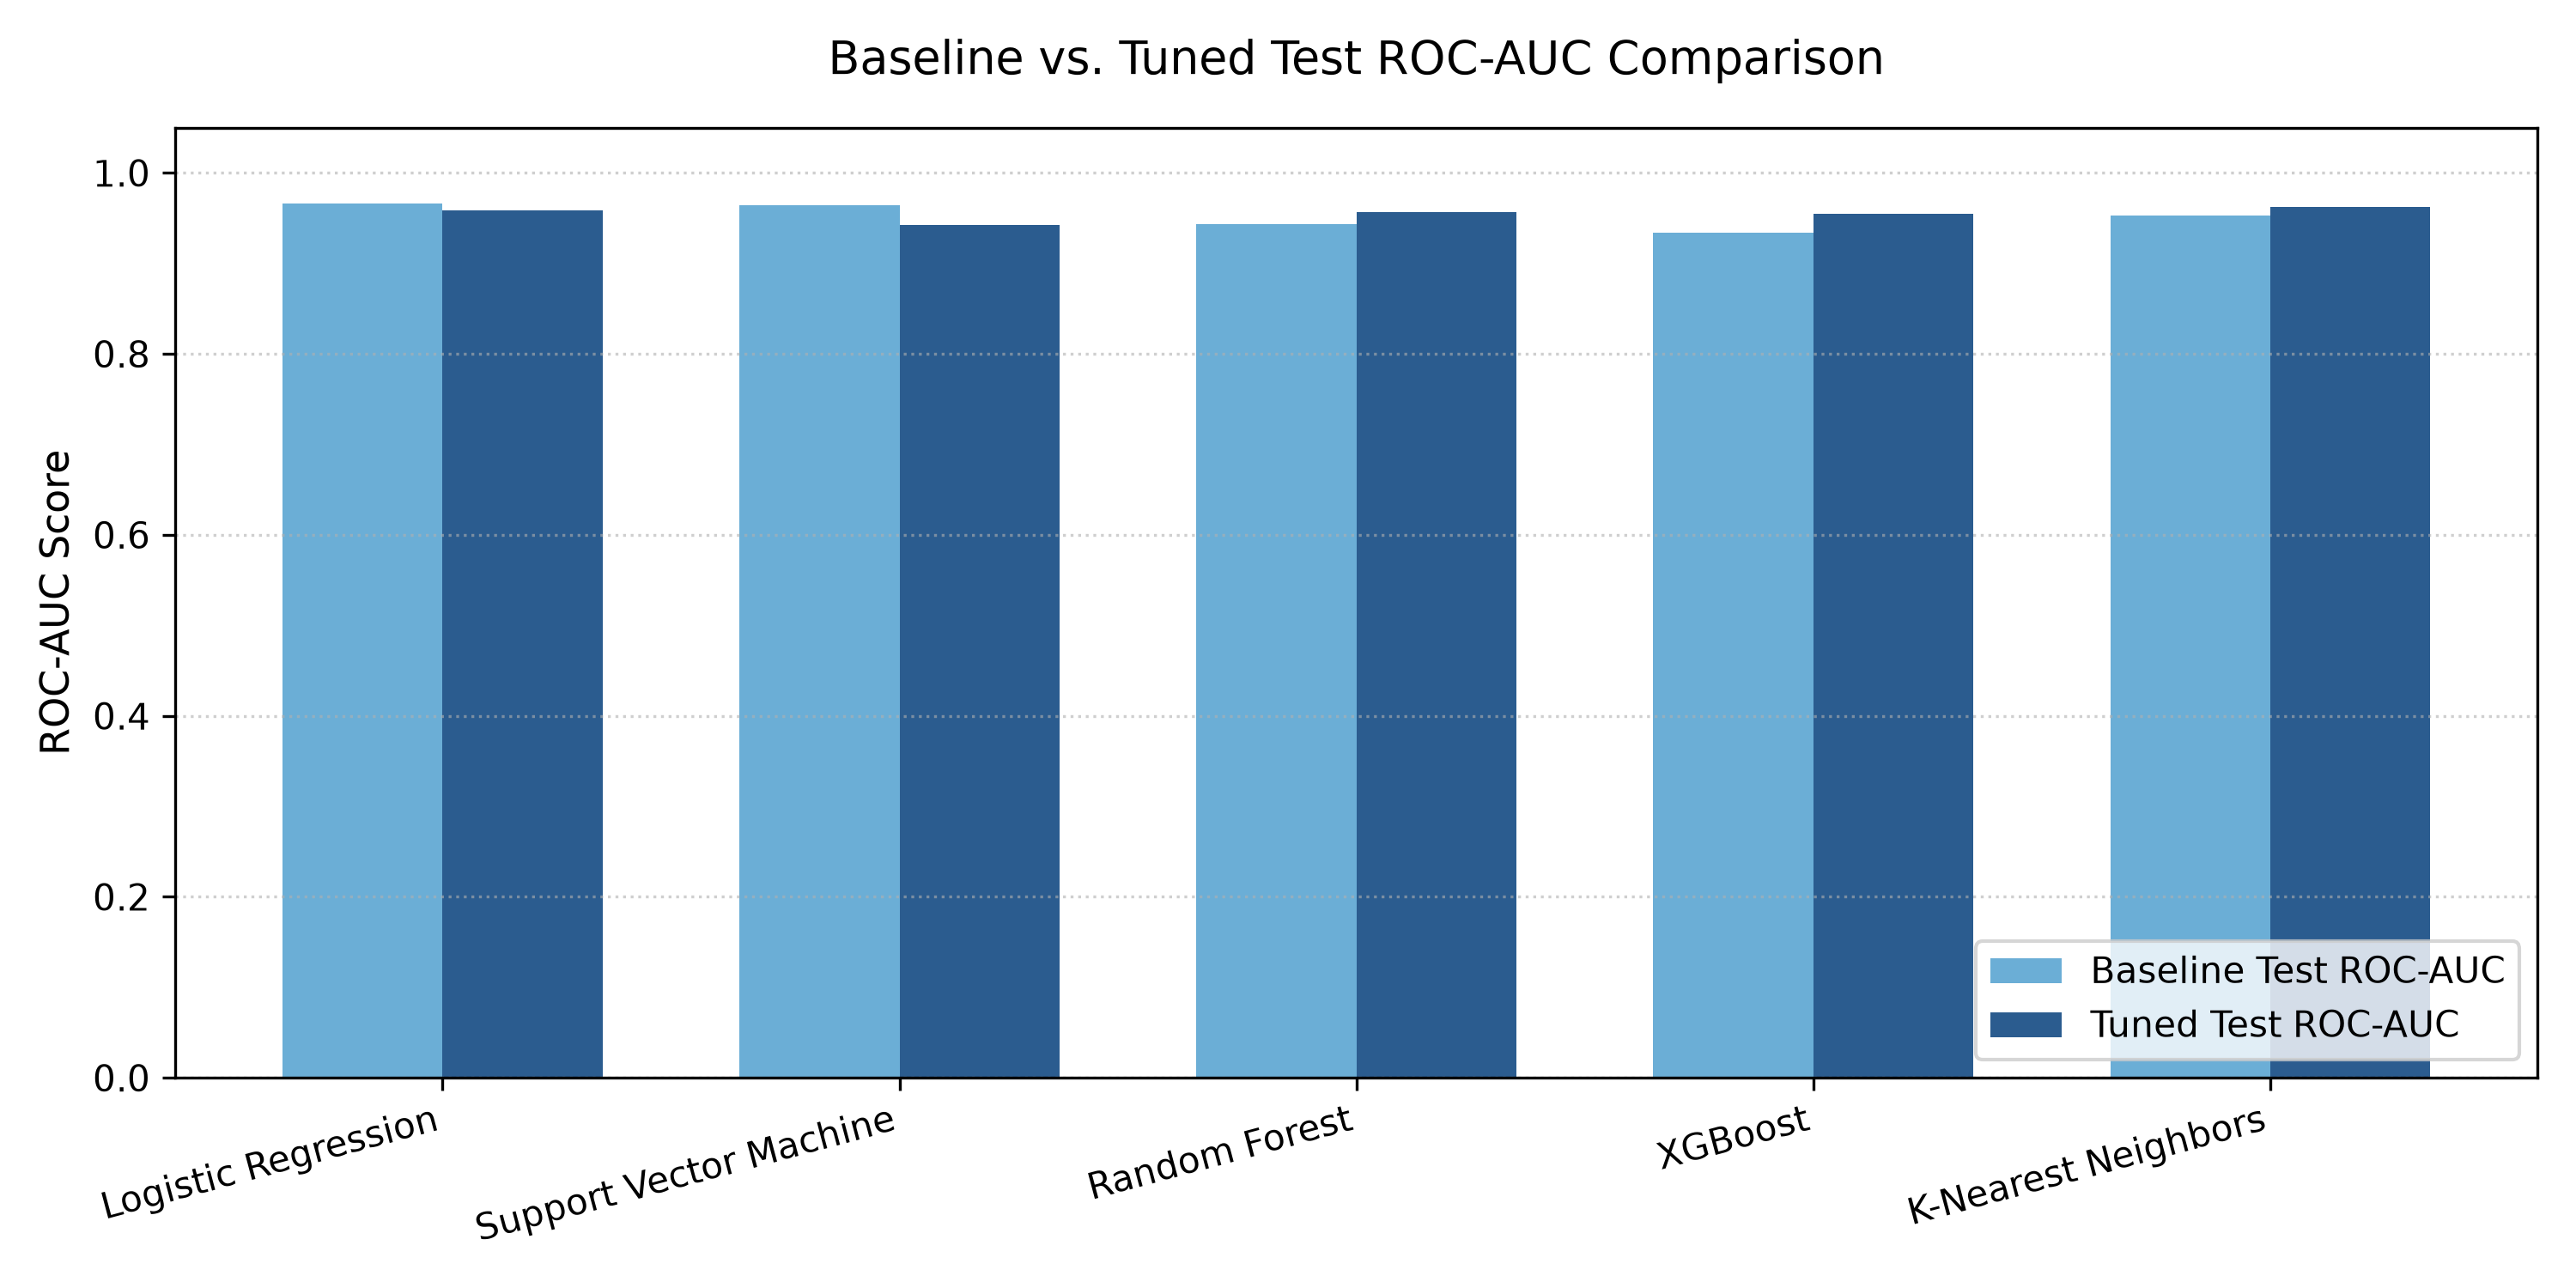

In [8]:
roc_curves_file = fig_dir / "tuned_roc_curves.png"
if roc_curves_file.exists():
    display(Image(filename=str(roc_curves_file)))

roc_auc_comp_file = fig_dir / "baseline_vs_tuned_roc_auc.png"
if roc_auc_comp_file.exists():
    display(Image(filename=str(roc_auc_comp_file)))


## 14. False-Negative Analysis

False-negative counts for baseline vs tuned models (Class 1 = Heart Disease Present):


In [9]:
fn_df = pd.read_csv(metrics_dir / "false_negative_comparison.csv")
fn_df


,Model,Baseline_FN,Tuned_FN,FN_Change
0,Logistic Regression,2,3,1
1,Support Vector Machine,2,4,2
2,Random Forest,2,1,-1
3,XGBoost,2,3,1
4,K-Nearest Neighbors,3,3,0


## 15. Limitations

- **Small Dataset Size**: Total 303 rows (242 train, 61 test). Small sample variations can cause metric shifts.
- **No Clinical Claims**: Results demonstrate methodological rigor on this held-out split; no claims of clinical validity or production readiness are made.
- **Search Space Scope**: Hyperparameter grid search ranges were kept computationally reasonable for educational purposes.


## 16. Conclusion

Hyperparameter tuning successfully optimized model candidate configurations on the training set using Stratified 5-Fold CV ROC-AUC without accessing the held-out test set. All tuned model pipelines were saved to `models/tuned/` for final model selection in Part 7.
